In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# === 1. POIDS DE PONDÉRATION ===
W_EXPOSITION = {"Internet": 2.0, "DMZ": 1.5, "Interne": 1.0}
W_CRITICITE  = {"Critique": 2.0, "Élevée": 1.5, "Moyenne": 1.0, "Faible": 0.5}
W_DONNEES    = {"Sensible": 1.5, "Interne": 1.0, "Public": 0.5}

SRC_MAX_THEORIQUE = 10.0 * 2.0 * 2.0 * 1.5  # = 60.0

In [3]:
# === 2. CHARGEMENT DES DONNÉES ===
vulns = pd.read_csv("data/payshield_vulns.csv")
infra = pd.read_csv("data/payshield_infrastructure.csv")

display(vulns.head(), vulns.shape)
display(vulns.head(), vulns.shape)

,id,ip,port,service,version,cvss,cve,epss,exposition,criticite,donnees,description,kev
0,V01,10.0.0.10,443,OpenSSL,1.0.1,10.0,CVE-2014-0160,0.97,Internet,Critique,Sensible,Heartbleed — fuite mémoire SSL pouvant exposer...,1
1,V02,10.0.0.10,80,Apache,2.4.49,9.8,CVE-2021-41773,0.96,Internet,Critique,Sensible,Path traversal et RCE sans authentification su...,1
2,V03,10.0.0.10,22,OpenSSH,7.4,7.8,CVE-2018-15473,0.12,Internet,Critique,Sensible,Enumération des noms d'utilisateurs valides vi...,0
3,V04,10.0.0.10,8443,Node.js,14.0,8.1,CVE-2021-22931,0.08,Internet,Critique,Sensible,Corruption mémoire dans le runtime Node.js — p...,0
4,V05,10.0.0.15,5432,PostgreSQL,12.3,10.0,-,0.45,Interne,Critique,Sensible,Compte postgres sans mot de passe — accès root...,0


(35, 13)

,id,ip,port,service,version,cvss,cve,epss,exposition,criticite,donnees,description,kev
0,V01,10.0.0.10,443,OpenSSL,1.0.1,10.0,CVE-2014-0160,0.97,Internet,Critique,Sensible,Heartbleed — fuite mémoire SSL pouvant exposer...,1
1,V02,10.0.0.10,80,Apache,2.4.49,9.8,CVE-2021-41773,0.96,Internet,Critique,Sensible,Path traversal et RCE sans authentification su...,1
2,V03,10.0.0.10,22,OpenSSH,7.4,7.8,CVE-2018-15473,0.12,Internet,Critique,Sensible,Enumération des noms d'utilisateurs valides vi...,0
3,V04,10.0.0.10,8443,Node.js,14.0,8.1,CVE-2021-22931,0.08,Internet,Critique,Sensible,Corruption mémoire dans le runtime Node.js — p...,0
4,V05,10.0.0.15,5432,PostgreSQL,12.3,10.0,-,0.45,Interne,Critique,Sensible,Compte postgres sans mot de passe — accès root...,0


(35, 13)

In [4]:
# === 3. CALCUL DU SRC ===
vulns["w_exposition"] = vulns["exposition"].map(W_EXPOSITION)
vulns["w_criticite"]  = vulns["criticite"].map(W_CRITICITE)
vulns["w_donnees"]    = vulns["donnees"].map(W_DONNEES)

vulns["src"]      = vulns["cvss"] * vulns["w_exposition"] * vulns["w_criticite"] * vulns["w_donnees"]
vulns["src_norm"] = (vulns["src"] / SRC_MAX_THEORIQUE * 10).round(2)



In [7]:
# === 4. TOP 10 ===
from IPython.core.display_functions import display
top10 = (
    vulns[["id", "ip", "service", "cve", "cvss", "exposition", "criticite", "donnees", "src_norm", "description"]]
    .sort_values("src_norm", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1

print("=" * 80)
print("TOP 10 VULNÉRABILITÉS — Score de Risque Contextuel (SRC normalisé)")
print("=" * 80)
display(top10[["id", "ip", "service", "cve", "cvss", "src_norm", "description"]])




TOP 10 VULNÉRABILITÉS — Score de Risque Contextuel (SRC normalisé)


,id,ip,service,cve,cvss,src_norm,description
1,V01,10.0.0.10,OpenSSL,CVE-2014-0160,10.0,10.00,Heartbleed — fuite mémoire SSL pouvant exposer...
2,V02,10.0.0.10,Apache,CVE-2021-41773,9.8,9.80,Path traversal et RCE sans authentification su...
3,V34,10.0.0.10,Kubernetes API,CVE-2020-8554,9.8,9.80,Man-in-the-middle via ExternalIP services — in...
4,V04,10.0.0.10,Node.js,CVE-2021-22931,8.1,8.10,Corruption mémoire dans le runtime Node.js — p...
5,V03,10.0.0.10,OpenSSH,CVE-2018-15473,7.8,7.80,Enumération des noms d'utilisateurs valides vi...
6,V11,10.0.0.25,Keycloak,CVE-2021-3461,9.8,7.35,Contournement d'authentification SSO via token...
7,V21,10.0.0.40,pfSense,CVE-2021-41282,9.8,6.53,Injection de commandes shell dans l'interface ...
8,V12,10.0.0.25,Keycloak,CVE-2020-1714,8.1,6.07,Injection de code côté serveur via template Fr...
9,V22,10.0.0.40,pfSense,CVE-2022-31814,8.8,5.87,CSRF permettant la modification de règles fire...
10,V23,10.0.0.40,OpenSSH,CVE-2023-38408,7.8,5.20,RCE via agent SSH forwarding dans OpenSSH < 9.3


In [9]:
plt.bar??

Signature:
plt.bar(
    x: 'float | ArrayLike',
    height: 'float | ArrayLike',
    width: 'float | ArrayLike' = 0.8,
    bottom: 'float | ArrayLike | None' = None,
    *,
    align: "Literal['center', 'edge']" = 'center',
    data=None,
    **kwargs,
) -> 'BarContainer'
Docstring:
Make a bar plot.

The bars are positioned at *x* with the given *align*\ment. Their
dimensions are given by *height* and *width*. The vertical baseline
is *bottom* (default 0).

Many parameters can take either a single value applying to all bars
or a sequence of values, one for each bar.

Parameters
----------
x : float or array-like
    The x coordinates of the bars. See also *align* for the
    alignment of the bars to the coordinates.

    Bars are often used for categorical data, i.e. string labels below
    the bars. You can provide a list of strings directly to *x*.
    ``bar(['A', 'B', 'C'], [1, 2, 3])`` is often a shorter and more
    convenient notation compared to
    ``bar(range(3), [1, 2, 3], ti

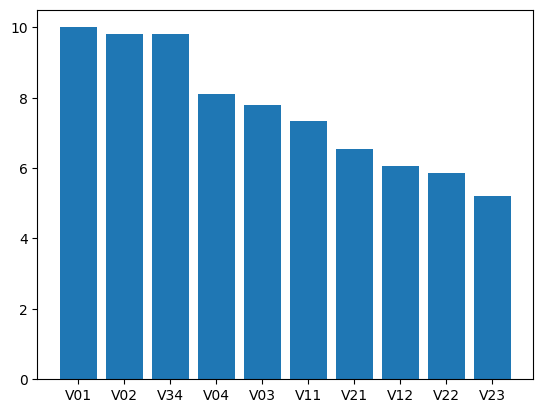

In [16]:
plt.bar(top10["id"], top10["src_norm"])
plt.show()

In [14]:

# === 5. RÉSUMÉ PAR HÔTE ===
resume = (
    vulns.groupby("ip")
    .agg(
        src_max=("src_norm", "max"),
        nb_vulns=("id", "count")
    )
    .reset_index()
)

resume = resume.merge(
    infra[["ip", "nom", "role"]],
    on="ip",
    how="left"
)

resume = resume.sort_values("src_max", ascending=False).reset_index(drop=True)
resume.index += 1

print("=" * 80)
print("RÉSUMÉ PAR HÔTE")
print("=" * 80)
print(resume[["ip", "nom", "role", "src_max", "nb_vulns"]].to_string())
print()

RÉSUMÉ PAR HÔTE
           ip          nom                                                                        role  src_max  nb_vulns
1   10.0.0.10      pay-api                              API paiement mobile — 15 000 transactions/jour    10.00         5
2   10.0.0.25     auth-srv           Serveur SSO — gestion des identités et accès de tous les employés     7.35         4
3   10.0.0.40        fw-01  Firewall périmétrique principal — tout le trafic entrant/sortant passe ici     6.53         4
4   10.0.0.15      db-prod                      Base de données transactions + KYC — 1.2M utilisateurs     5.00         3
5   10.0.0.20    web-front                   Portail web clients — authentification et tableau de bord     3.90         3
6   10.0.0.50       backup          Serveur de sauvegardes chiffrées — snapshots quotidiens de db-prod     2.70         3
7   10.0.0.30  admin-panel             Backoffice opérateurs PayShield — gestion des comptes marchands     2.45         4
8   10.0